# XDMoD and CloudBank — Introductory Notebook

Compatible with XDMoD Data Analytics Framework v≥1.0.0 and <2.0.0

See the [xdmod-notebooks](https://github.com/ubccr/xdmod-notebooks) repository for information on setup, support, contributing, licensing, and referencing. See there the Intro notebook on which this one is based!

## Introduction

The XDMoD Data Analytics Framework provides API access to the data in an XDMoD portal via the [xdmod_data](https://pypi.org/project/xdmod-data) Python package. This notebook provides an introductory explanation of how to use the package. You will use the XDMoD API to request data, load them into [Pandas](https://pandas.pydata.org/) [DataFrames](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html), and generate plots.

The XDMoD Data Analytics Framework can be run either in an XDMoD-hosted JupyterHub (e.g., by clicking the "JupyterLab" button in ACCESS XDMoD) or locally on your machine.

## Install/upgrade the required modules

Run the code below to install/upgrade the packages needed to run this notebook.

In [51]:
import sys
! {sys.executable} -m pip install --upgrade 'xdmod-data[report]>=1.0.0,<2.0.0' python-dotenv tabulate

If running that code caused a new version of Plotly to be installed/upgraded, you may need to refresh your browser window for plots to appear correctly.

## Configure notebook formatting

### Exceptions

Run the code below to simplify how Python exceptions are displayed in this notebook.

In [2]:
import sys
def exception_handler(exception_type, exception, traceback):
    print("%s: %s" % (exception_type.__name__, exception), file=sys.stderr)
get_ipython()._showtraceback = exception_handler

### Tables

Run the code below to set up for displaying Pandas DataFrames as Markdown tables in this notebook.

In [3]:
from IPython.display import display, Markdown
def display_df_md_table(df):
    return display(Markdown(df.replace('\n', '<br/>', regex=True).to_markdown()))

### Plots

Set up the external Plotly package to make plots using a custom XDMoD theme.

In [4]:
import plotly.express as px
import plotly.io as pio
import xdmod_data.themes
pio.templates.default = 'timeseries'

## Authenticate with XDMoD

To run in a Jupyter Lab environment, you must first obtain an API token from the XDMoD portal. Save it to a file that can be accessed by the Jupyter environment (e.g., in the home directory at `~/xdmod-data.env`) with the contents `XDMOD_API_TOKEN=my_token`. This file should be saved with `600` permissions (user read/write only). 

To obtain an API token from the XDMoD portal follow [these instructions](https://github.com/ubccr/xdmod-data#api-token-access).

When run, the code cell below will read your token from `~/xdmod-data.env` into the environment, which will be used later when you start running methods from the API. It will print `True` if it successfully loaded the file.

In [52]:
from dotenv import load_dotenv
from os.path import expanduser
from pathlib import Path

# load local env file with API token:
load_dotenv(Path(expanduser('~/xdmod-data.env')), 
            override=True)

## Initialize the DataWarehouse object

Run the code below to initialize a `DataWarehouse` object that will be used for making the API calls to Production XDMoD.

We assume here that you are running in a local Jupyter Lab environment (not an XDMoD hosted JupyterHub). So, we specify the URL of the XDMoD portal as a string parameter to the `DataWarehouse` constructor (Alternately we could set the `XDMOD_HOST` environment variable).

In [6]:
# Connect to the production data warehouse
from xdmod_data.warehouse import DataWarehouse
dw = DataWarehouse("https://xdmod.access-ci.org")

In [53]:
# verify the version of the data connector in use here:
from xdmod_data import __version__
print(__version__)

## Get the data

Run the code below to use the `get_data()` method to request data from XDMoD and load them into a Pandas DataFrame. This example gets the total CloudBank spend over a 4-month period. Here we use `with` to create a runtime context; this is explained later in this notebook.

In [8]:
with dw:
    df = dw.get_data(
        duration=('2026-01-01', '2026-04-30'),
        realm='CloudBankSpend',
        metric='cb_spend',
    )
display(df)

Metric,Total Spend (USD)
Time,
2026-01-01,4695.711131
2026-01-02,6264.786834
2026-01-03,5694.305617
2026-01-04,5706.624373
2026-01-05,6168.129496
...,...
2026-04-26,10708.161075
2026-04-27,20498.438645
2026-04-28,10294.193937


Note that the `df` object is a Pandas DataFrame:

In [9]:
type(df)

pandas.DataFrame

## Plot the data

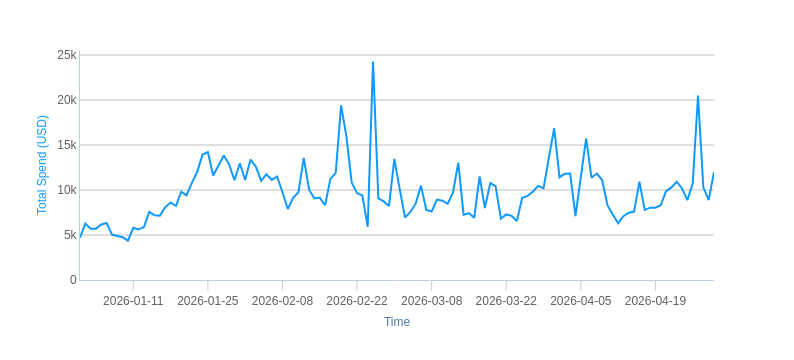

In [10]:
plot = px.line(df, y='Total Spend (USD)')
plot.show()

## Additional data processing

You can do further processing on the DataFrame to produce analysis and plots beyond those that are available in the XDMoD portal.

Run the code below to add a column for the day of the week:

In [11]:
df['Day Name'] = df.index.strftime('%a')
display(df)

Metric,Total Spend (USD),Day Name
Time,,
2026-01-01,4695.711131,Thu
2026-01-02,6264.786834,Fri
2026-01-03,5694.305617,Sat
2026-01-04,5706.624373,Sun
2026-01-05,6168.129496,Mon
...,...,...
2026-04-26,10708.161075,Sun
2026-04-27,20498.438645,Mon
2026-04-28,10294.193937,Tue


Run the code below to show a box plot of the data grouped by day of the week:

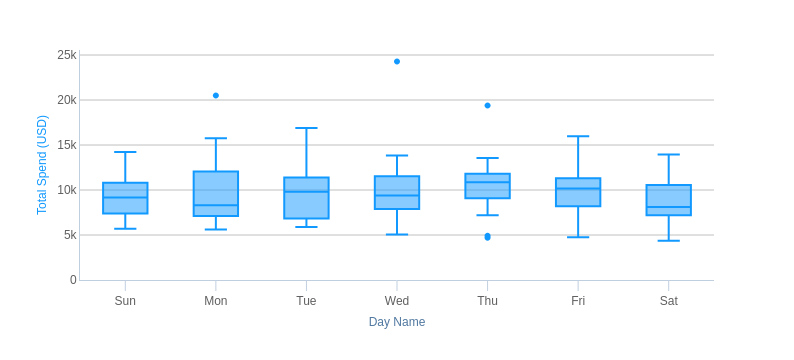

In [12]:
plot = px.box(
    df,
    x='Day Name',
    y='Total Spend (USD)',
    category_orders={'Day Name': ('Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat')},
)
plot.show()

## Details of the `get_data()` method

Now that you have seen a basic example of using the `get_data()` method, read below for more details on how it works.

### Wrap data warehouse calls in a runtime context

XDMoD data are accessed over a network connection, which involves establishing connections and creating temporary resources. To ensure these connections and resources are cleaned up properly in spite of any runtime errors, you should call data warehouse methods within a **runtime context** by using Python's `with` statement to wrap the execution of XDMoD queries, store the result, and execute any long running calculations outside of the runtime context, as in the template below.

In [28]:
with dw:
    # XDMoD queries would go here
    pass
# Data processing would go here
pass

### Default parameters

The `get_data()` method has a number of parameters; their default values are shown below, and the parameters are explained in more detail further below.

In [29]:
# Default values for get_data()
#with dw:
#    df = dw.get_data(
#        duration='Previous month',
#        realm='Jobs',
#        metric='CPU Hours: Total',
#        dimension='None',
#        filters={},
#        dataset_type='timeseries',
#        aggregation_unit='Auto',
#    )

In [30]:
# Let's get some cloudbank data
with dw:
    df = dw.get_data(
        duration='1 year',
        realm='CloudBankSpend',
        metric='cb_spend',
        dimension='None',
        filters={},
        dataset_type='timeseries',
        aggregation_unit='Auto',
    )

### Duration

The **duration** provides the time constraints of the data to be fetched from the XDMoD data warehouse.

As already seen, you can specify the duration as start and end times:

In [31]:
with dw:
    df = dw.get_data(duration=('2023-01-01', '2023-04-30'))

You can instead specify the duration using a special string value; a list of the valid values can be obtained by calling the `get_durations()` method.

In [32]:
with dw:
    durations = dw.get_durations()
display(durations)

('Yesterday',
 '7 day',
 '30 day',
 '90 day',
 'Month to date',
 'Previous month',
 'Quarter to date',
 'Previous quarter',
 'Year to date',
 'Previous year',
 '1 year',
 '2 year',
 '3 year',
 '5 year',
 '10 year',
 '2026',
 '2025',
 '2024',
 '2023',
 '2022',
 '2021',
 '2020')

### Realm

A **realm** is a category of data in the XDMoD data warehouse. You can use the `describe_realms()` method to get a DataFrame containing the list of available realms.

In [33]:
with dw:
    realms = dw.describe_realms()
display_df_md_table(realms)

| id                     | label                   |
|:-----------------------|:------------------------|
| Accounts               | Accounts                |
| Allocations            | Allocations             |
| Cloud                  | Cloud                   |
| CloudBankFunds         | CloudBank Funds         |
| CloudBankSpend         | CloudBank Spend         |
| Gateways               | Gateways                |
| Jobs                   | Jobs                    |
| Requests               | Requests                |
| ResourceSpecifications | Resource Specifications |
| SUPREMM                | SUPREMM                 |

### Metric

A **metric** is a statistic for which data exists in a given realm. You can use the `describe_metrics(realm)` method to get a DataFrame containing the list of valid metrics in the given realm. The realm must be passed in as a string.

In [34]:
with dw:
    metrics = dw.describe_metrics('CloudBankSpend')
display_df_md_table(metrics)

| id                      | label                            | description                                                                                                                                                                                    |
|:------------------------|:---------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| cb_active_account_count | Number of Cloud Accounts: Active | The total number of cloud accounts that spent money on public cloud services. Money is deposited into a fund from which it is dispersed to cloud provider accounts to cover charges for usage. |
| cb_active_fund_count    | Number of Funds: Active          | The total number of funds that spent money on public cloud services. Money is deposited into a fund from which it is dispersed to cloud provider accounts to cover charges for usage.          |
| cb_active_pi_count      | Number of PIs: Active            | The total number of principal investigators on the fund(s) that spent money on public cloud services.                                                                                          |
| cb_spend                | Total Spend (USD)                | The amount of money (in USD) spent by funds on public cloud services.                                                                                                                          |

In [35]:
with dw:
    metrics = dw.describe_metrics('CloudBankFunds')
display_df_md_table(metrics)

| id                  | label                   | description                                                                     |
|:--------------------|:------------------------|:--------------------------------------------------------------------------------|
| cb_total_fund_count | Number of Funds: Active | The total number of funds that could have spent money on public cloud services. |

### Dimension

A **dimension** is a grouping of data. You can use the `describe_dimensions(realm)` method to get a DataFrame containing the list of valid dimensions in the given realm. The realm must be passed in as a string.

In [36]:
with dw:
    dimensions = dw.describe_dimensions('CloudBankFunds')
display_df_md_table(dimensions)

| id                                              | label                                                      | description                                                                                                                                                                    |
|:------------------------------------------------|:-----------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| none                                            | None                                                       | Information about funds that could have spent money on public cloud services via the NSF CloudBank project.                                                                    |
| cb_field_of_science                             | Field of Science                                           | The branch of science under which a fund's research falls.                                                                                                                     |
| cb_pi                                           | Fund PI                                                    | The principal investigator on the fund(s) that could have spent money on public cloud services.                                                                                |
| cb_pi_institution                               | Fund PI Institution                                        | The primary institution of the principal investigator(s) on the fund(s) that could have spent money on public cloud services.                                                  |
| cb_pi_institution_carnegie_classification       | Fund PI Institution Carnegie Classification                | The Carnegie Classification of the primary institution(s) of the principal investigator(s) on the fund(s) that could have spent money on public cloud services.                |
| cb_pi_institution_carnegie_research_designation | Fund PI Institution Carnegie Research Activity Designation | The Carnegie Research Activity Designation of the primary institution(s) of the principal investigator(s) on the fund(s) that could have spent money on public cloud services. |
| cb_pi_institution_city                          | Fund PI Institution City                                   | The city in which the primary institution(s) of the principal investigator(s) on the fund(s) that could have spent money on public cloud services are located.                 |
| cb_pi_institution_country                       | Fund PI Institution Country                                | The country in which the primary institution(s) of the principal investigator(s) on the fund(s) that could have spent money on public cloud services are located.              |
| cb_pi_institution_epscor                        | Fund PI Institution EPSCoR                                 | Whether the primary institution(s) of the principal investigator(s) on the fund(s) that could have spent money on public cloud services are in an EPSCoR jurisdiction.         |
| cb_pi_institution_state                         | Fund PI Institution State                                  | The state in which the primary institution(s) of the principal investigator(s) on the fund(s) that could have spent money on public cloud services are located.                |
| cb_funder                                       | Funding Source                                             | The funding source that awarded the fund(s) that could have spent money on public cloud services.                                                                              |
| cb_nsf_division                                 | Funding Source Division                                    | The NSF Division that awarded the fund(s) that could have spent money on public cloud services. For non-NSF funding sources, this value will be "Unknown.".                    |

In [37]:
with dw:
    dimensions = dw.describe_dimensions('CloudBankSpend')
display_df_md_table(dimensions)

| id                                              | label                                                      | description                                                                                                                                                                                                                                                                                            |
|:------------------------------------------------|:-----------------------------------------------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| none                                            | None                                                       | Information about funds that spent money on public cloud services via the NSF CloudBank project.                                                                                                                                                                                                       |
| cb_location                                     | Cloud Location                                             | The geographical location where cloud providers cluster data centers to provide services.                                                                                                                                                                                                              |
| cb_cloud_provider                               | Cloud Provider                                             | A provider of cloud services, e.g. Amazon Web Services (AWS), Microsoft Azure, Google Cloud Platform (GCP).                                                                                                                                                                                            |
| cb_account                                      | Cloud Provider Account                                     | A cloud provider specific financial account that is charged for usage.                                                                                                                                                                                                                                 |
| cb_service                                      | Cloud Service                                              | The particular cloud provider service on which funds spent money.                                                                                                                                                                                                                                      |
| cb_sub_service                                  | Cloud Sub-Service                                          | Within each cloud service there may be one or more sub-services that are charged at different rates (e.g., when using AWS's EC2 service, in addition to being charged for instance time, you are also charged for data transfer, file storage etc. These are seen as sub-services of the EC2 service). |
| cb_field_of_science                             | Field of Science                                           | The branch of science under which a fund's research falls.                                                                                                                                                                                                                                             |
| cb_fund                                         | Fund                                                       | The fund that spent money on public cloud services. Money is deposited into a fund from which it is dispersed to cloud provider accounts to cover charges for usage.                                                                                                                                   |
| cb_pi                                           | Fund PI                                                    | The principal investigator on the fund(s) that spent money on public cloud services.                                                                                                                                                                                                                   |
| cb_pi_institution                               | Fund PI Institution                                        | The primary institution of the principal investigator(s) on the fund(s) that spent money on public cloud services.                                                                                                                                                                                     |
| cb_pi_institution_carnegie_classification       | Fund PI Institution Carnegie Classification                | The Carnegie Classification for the primary institution(s) of the principal investigator(s) on the fund(s) that spent money on public cloud services.                                                                                                                                                  |
| cb_pi_institution_carnegie_research_designation | Fund PI Institution Carnegie Research Activity Designation | The Carnegie Research Activity Designation for the primary institution(s) of the principal investigator(s) on the fund(s) that spent money on public cloud services.                                                                                                                                   |
| cb_pi_institution_city                          | Fund PI Institution City                                   | The city in which the primary institution(s) of the principal investigator(s) on the fund(s) that spent money on public cloud services are located.                                                                                                                                                    |
| cb_pi_institution_country                       | Fund PI Institution Country                                | The country in which the primary institution(s) of the principal investigator(s) on the fund(s) that spent money on public cloud services are located.                                                                                                                                                 |
| cb_pi_institution_epscor                        | Fund PI Institution EPSCoR                                 | Whether the primary institution(s) of the principal investigator(s) on the fund(s) that spent money on public cloud services are in an EPSCoR jurisdiction.                                                                                                                                            |
| cb_pi_institution_state                         | Fund PI Institution State                                  | The state in which the primary institution(s) of the principal investigator(s) on the fund(s) that spent money on public cloud services are located.                                                                                                                                                   |
| cb_funder                                       | Funding Source                                             | The funding source that awarded the fund(s) that spent money on public cloud services.                                                                                                                                                                                                                 |
| cb_nsf_directorate                              | Funding Source Directorate                                 | The NSF Directorate that awarded the fund(s) that spent money on public cloud services. For non-NSF funding sources, this value will be. For non-NSF funding sources, this value will be "Unknown".                                                                                                    |
| cb_nsf_division                                 | Funding Source Division                                    | The NSF Division that awarded the fund(s) that spent money on public cloud services. For non-NSF funding sources, this value will be "Unknown."                                                                                                                                                        |

The code below shows how to get data grouped by the `Funding Source` dimension and plot them.

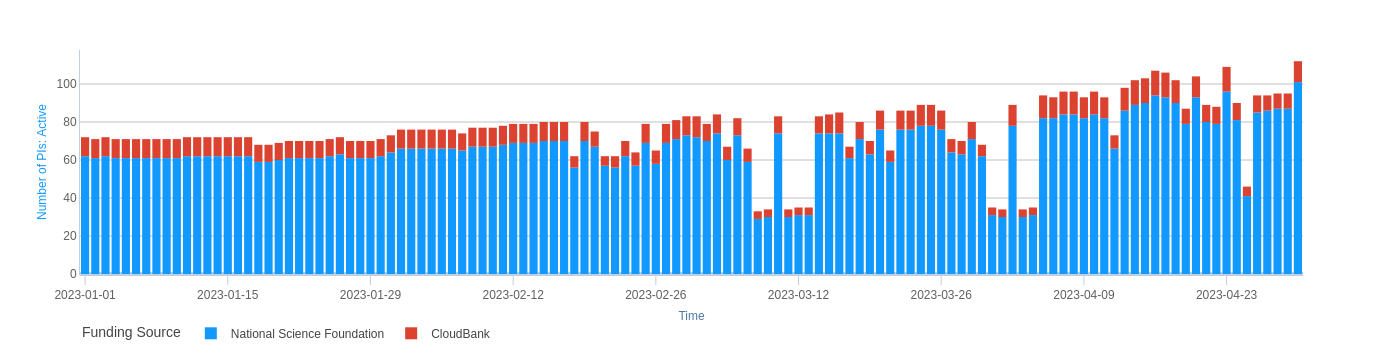

In [38]:
metric_label = 'Number of PIs: Active'
with dw:
    df = dw.get_data(
        duration=('2023-01-01', '2023-04-30'),
        realm='CloudBankSpend',
        metric=metric_label,
        dimension='cb_funder', 
    )
plot = px.bar(df, labels={'value': metric_label})
plot.show()

### Pass in realms, metrics, and dimensions using labels or IDs

For methods in the API that take realms, metrics, and/or dimensions as arguments, you can pass them in as their labels or their IDs.

In [39]:
with dw:
    df = dw.get_data(
        duration='1 year',
        realm='CloudBankFunds',
        metric='cb_total_fund_count', # this is an ID, but you could use its label instead
        dimension='cb_funder', # this is an ID, but you could use its label instead ("Funding Source")
    )

### Filters

**Filters** allow you to include only data that have certain values for given dimensions. You can use the `get_filter_values(realm, dimension)` method to get a DataFrame containing the list of valid filter values for the given dimension in the given realm. The realm and dimension must be passed in as strings.

In [40]:
with dw:
    filter_values = dw.get_filter_values('CloudBankSpend', 'cb_location') # 'Cloud Location' also works here
display_df_md_table(filter_values)

|   id | label                   |
|-----:|:------------------------|
|    1 |                         |
|    2 | AE North                |
|    3 | af-south-1              |
|    4 | af-south-1-los-1        |
|    5 | africa-south1           |
|    6 | All                     |
|    7 | allregions              |
|    8 | AP Southeast            |
|    9 | ap-east-1               |
|   10 | ap-northeast-1          |
|   11 | ap-northeast-1-tpe-1    |
|   12 | ap-northeast-2          |
|   13 | ap-northeast-3          |
|   14 | ap-south-1              |
|   15 | ap-south-1-del-1        |
|   16 | ap-south-2              |
|   17 | ap-southeast-1          |
|   18 | ap-southeast-2          |
|   19 | ap-southeast-3          |
|   20 | ap-southeast-4          |
|   21 | ap-southeast-5          |
|   22 | Asia                    |
|   23 | asia-east1              |
|   24 | asia-east2              |
|   25 | asia-northeast1         |
|   26 | asia-northeast2         |
|   27 | asia-northeast3         |
|   28 | asia-south1             |
|   29 | asia-south2             |
|   30 | asia-southeast1         |
|   31 | asia-southeast2         |
|   32 | AU East                 |
|   33 | Australia Central       |
|   34 | Australia East          |
|   35 | Australia Southeast     |
|   36 | australia-southeast1    |
|   37 | australia-southeast2    |
|   38 | BR South                |
|   39 | Brazil South            |
|   40 | CA Central              |
|   41 | CA East                 |
|   42 | ca-central-1            |
|   43 | ca-west-1               |
|   44 | Canada Central          |
|   45 | Canada East             |
|   46 | Central India           |
|   47 | Central US              |
|   48 | DE West Central         |
|   49 | East Asia               |
|   50 | East US                 |
|   51 | East US 2               |
|   52 | EU North                |
|   53 | EU West                 |
|   54 | eu-central-1            |
|   55 | eu-central-1-ham-1      |
|   56 | eu-central-1-waw-1      |
|   57 | eu-central-2            |
|   58 | eu-north-1              |
|   59 | eu-south-1              |
|   60 | eu-south-2              |
|   61 | eu-west-1               |
|   62 | eu-west-2               |
|   63 | eu-west-3               |
|   64 | Europe                  |
|   65 | europe-central2         |
|   66 | europe-north1           |
|   67 | europe-southwest1       |
|   68 | europe-west1            |
|   69 | europe-west10           |
|   70 | europe-west12           |
|   71 | europe-west2            |
|   72 | europe-west3            |
|   73 | europe-west4            |
|   74 | europe-west6            |
|   75 | europe-west8            |
|   76 | europe-west9            |
|   77 | FR Central              |
|   78 | France Central          |
|   79 | Germany West Central    |
|   80 | global                  |
|   81 | il-central-1            |
|   82 | Intercontinental        |
|   83 | israelcentral           |
|   84 | IT North                |
|   85 | italynorth              |
|   86 | JA East                 |
|   87 | JA West                 |
|   88 | Japan East              |
|   89 | Japan West              |
|   90 | Korea Central           |
|   91 | Korea South             |
|   92 | me-central-1            |
|   93 | me-central1             |
|   94 | me-central2             |
|   95 | me-south-1              |
|   96 | me-west1                |
|   97 | mexicocentral           |
|   98 | multi-region            |
|   99 | mx-central-1            |
|  100 | newzealandnorth         |
|  101 | North America           |
|  102 | North Central US        |
|  103 | North Europe            |
|  104 | northamerica-northeast1 |
|  105 | northamerica-northeast2 |
|  106 | northamerica-south1     |
|  107 | norwayeast              |
|  108 | PL Central              |
|  109 | polandcentral           |
|  110 | qatarcentral            |
|  111 | sa-east-1               |
|  112 | SE Central              |
|  113 | South Africa North      |
|  114 | South Central US        |
|  115 | South East Asia         |
|  116 | South India             |
|  117 | southamerica-east1      |
|  118 | southamerica-west1      |
|  119 | spaincentral            |
|  120 | swedencentral           |
|  121 | Switzerland North       |
|  122 | true                    |
|  123 | UAE North               |
|  124 | UK South                |
|  125 | UK West                 |
|  126 | Unassigned              |
|  127 | US Central              |
|  128 | US East                 |
|  129 | US East 2               |
|  130 | US North Central        |
|  131 | US South Central        |
|  132 | US West                 |
|  133 | US West 2               |
|  134 | US West 3               |
|  135 | US West Central         |
|  136 | us-central1             |
|  137 | us-central2             |
|  138 | us-east-1               |
|  139 | us-east-1-atl-1         |
|  140 | us-east-1-bos-1         |
|  141 | us-east-1-bue-1         |
|  142 | us-east-1-chi-1         |
|  143 | us-east-1-dfw-1         |
|  144 | us-east-1-iah-1         |
|  145 | us-east-1-lim-1         |
|  146 | us-east-1-mci-1         |
|  147 | us-east-1-mia-1         |
|  148 | us-east-1-msp-1         |
|  149 | us-east-1-nyc-1         |
|  150 | us-east-1-phl-1         |
|  151 | us-east-1-qro-1         |
|  152 | us-east-1-scl-1         |
|  153 | us-east-1-wl1           |
|  154 | us-east-1-wl1-nyc1      |
|  155 | us-east-2               |
|  156 | us-east1                |
|  157 | us-east2                |
|  158 | us-east4                |
|  159 | us-east5                |
|  160 | us-east7                |
|  161 | us-south1               |
|  162 | us-west-1               |
|  163 | us-west-2               |
|  164 | us-west-2-den-1         |
|  165 | us-west-2-hnl-1         |
|  166 | us-west-2-las-1         |
|  167 | us-west-2-lax-1         |
|  168 | us-west-2-pdx-1         |
|  169 | us-west-2-phx-1         |
|  170 | us-west-2-sea-1         |
|  171 | us-west1                |
|  172 | us-west2                |
|  173 | us-west3                |
|  174 | us-west4                |
|  175 | West Central US         |
|  176 | West Europe             |
|  177 | West India              |
|  178 | West US                 |
|  179 | West US 2               |
|  180 | West US 3               |
|  181 | Zone 1                  |
|  286 | austriaeast             |
|  287 | belgiumcentral          |
|  288 | chilecentral            |
|  289 | indonesiacentral        |
|  290 | malaysiawest            |
|  348 | us-central3             |
|  352 | europe-west11           |
|  353 | europe-west7            |
|  354 | us-west5                |
|  355 | us-west8                |
|  386 | europe-north2           |
|  445 | ID Central              |
|  462 | NO East                 |
|  501 | Oceania                 |
|  555 | denmarkeast             |
|  556 | indiasouthcentral       |
|  569 | us-east10               |
|  576 | ap east                 |
|  577 | at east                 |
|  578 | australiaeast           |
|  579 | be central              |
|  580 | centralus               |
|  581 | ch north                |
|  582 | cl central              |
|  583 | eastus                  |
|  584 | eastus2                 |
|  585 | es central              |
|  586 | il central              |
|  587 | in central              |
|  588 | kr central              |
|  589 | mx central              |
|  590 | my west                 |
|  591 | No Region: Custom       |
|  592 | No Region: Google Cloud |
|  593 | westus3                 |
|  594 | za north                |
|  617 | asia-southeast3         |

In [41]:
with dw:
    filter_values = dw.get_filter_values('CloudBankFunds', 'cb_funder') # Funding Source
display_df_md_table(filter_values)

|   id | label                       |
|-----:|:----------------------------|
|    1 | CloudBank                   |
|    2 | National Science Foundation |
|    3 | Strategic Blue              |
|    4 | NAIRR                       |
|    5 | Azure NAIRR Pilot Testing   |
|    6 | ACCESS                      |

In [42]:
with dw:
    filter_values = dw.get_filter_values('CloudBankFunds', 'cb_pi') # CloudBank PI
display_df_md_table(filter_values)

|   id | label                             |
|-----:|:----------------------------------|
| 2536 | Luis Amaral                       |
| 2250 | Abdullah Al-Mamun                 |
|  805 | Abhishek Dubey                    |
| 1226 | Abolfazl Asudeh                   |
| 1384 | Abraham I Matta                   |
| 5621 | Adam Bawatneh                     |
| 1102 | Adam Wierman                      |
| 2486 | Adarsh Krishnamurthy              |
| 2667 | Aditya Parameswaran               |
|  394 | Aditya Ramamoorthy                |
| 1809 | Ajay Jayant Joshi                 |
|  545 | Akane Sano                        |
|  362 | Alan Chalker                      |
|  707 | Alex Kamenev                      |
|  549 | Alexander Marder                  |
| 1115 | Ali Jannesari                     |
|  282 | Alisa Kang                        |
| 4475 | Alvin Cheung                      |
| 1362 | Ameeta Agrawal                    |
| 2397 | Amir Houmansadr                   |
| 4944 | AMIT CHOURASIA                    |
|  970 | Amy McGovern                      |
| 5278 | Amy Xu                            |
| 2631 | Ana Lucic                         |
| 1317 | Anand Panangadan                  |
|   25 | Andrea Zonca                      |
| 2081 | Andreas Molisch                   |
|  524 | Andrew Chien                      |
| 1143 | Andrew Lan                        |
| 1132 | Andrew Quinn                      |
| 2277 | Andrew White                      |
| 2013 | Andy Aschwanden                   |
| 5203 | Ang Li                            |
| 1328 | Anh Nguyen                        |
| 1031 | Animesh Chakravarthy              |
| 1515 | Anita Sarma                       |
| 1145 | Anna Feldman                      |
|  274 | Anna Klimaszewski-Patterson       |
| 5512 | Anne Marie Piper                  |
|  617 | Anshul Gandhi                     |
| 2299 | Anuj Sharma                       |
| 1227 | Anurag Anshu                      |
| 2432 | Anurag Khandelwal                 |
| 1587 | Ari Juels                         |
| 2216 | Ariel Rokem                       |
| 2075 | Arka Majumdar                     |
| 2484 | Armin Alipour                     |
|  518 | Arun Kumar                        |
|  830 | Ashwin Ashok                      |
| 1049 | Atlas Wang                        |
| 1225 | Audris Mockus                     |
|  563 | Austin Harris                     |
|  728 | Avani Wildani                     |
| 2487 | Avinash Sahu                      |
|  201 | Aws Albarghouthi                  |
| 4306 | Ayan Paul                         |
| 5251 | Azury Lin                         |
| 1096 | Bane V Vasic                      |
| 1087 | Bei Yan                           |
| 5378 | Ben Yu                            |
| 5627 | Benjamin Greenman                 |
| 2453 | Benjamin Lee                      |
| 5478 | Berkay Celik                      |
| 2773 | Bernadette Boscoe                 |
|  848 | Bhuwan Dhingra                    |
|  288 | Bill Conn                         |
| 1171 | Binghui Wang                      |
| 5529 | Binh Nguyen                       |
| 2797 | Biplav Srivastava                 |
| 2332 | Birendra Jha                      |
| 1693 | Bo Han                            |
| 4997 | Bo Wang                           |
| 2470 | Bo Xiao                           |
|  570 | Boyang Wang                       |
| 5268 | Brandon Budnicki                  |
| 2691 | Brendan O&#039;Connor             |
| 1165 | Brendan Saltaformaggio            |
|  125 | Brian Bockelman                   |
| 1037 | Bruno Ribeiro                     |
| 1167 | Carl Maltzahn                     |
|  263 | Carl Tape                         |
|  548 | Carlee Joe-Wong                   |
|  307 | Carlos Rubio Medrano              |
| 1357 | Carlos Wagmister                  |
|  287 | Casey Russell                     |
|  547 | Cesar Torres                      |
| 1088 | Chad Hanna                        |
| 1577 | Chao Zhang                        |
| 1599 | Chaowei Yang                      |
| 5581 | Charles McElroy                   |
|  285 | Charles Nguyen                    |
|  618 | Chen Ding                         |
|  482 | Chen Li                           |
|  923 | Chen Qian                         |
| 1176 | Cheng Tan                         |
| 1253 | Chengcui Zhang                    |
| 4385 | Chengze Li                        |
| 4446 | Chi-Fu Yang                       |
| 4988 | Chin Siang Ong                    |
| 1095 | Chris H Kim                       |
| 5357 | Chris Holdgraf                    |
| 1620 | Chris Re                          |
| 1070 | Christine Johnson                 |
|  960 | Christine Kirkpatrick             |
| 4429 | Christopher Amato                 |
| 5455 | Christopher Andrew Budiharto      |
| 2252 | Christopher Bizon                 |
|  640 | Christopher Myers                 |
| 1254 | Chuchu Fan                        |
| 1819 | Chun-Hua Tsai                     |
|  301 | Chutima Boonthum-Denecke          |
| 2657 | Cihang Xie                        |
| 1151 | Colleen Megowan-Romanowicz        |
|  610 | Collin McMillan                   |
| 5562 | Cong Gao                          |
| 1864 | Cuihua Shen                       |
| 2429 | Cynthia Chen                      |
| 2360 | Cyril Rakovski                    |
| 1595 | Cyrus Omar                        |
|  568 | Damon McCoy                       |
| 1618 | Dan Jurafsky                      |
|  470 | Dan Rubenstein                    |
| 2881 | Dana Habeeb                       |
| 2279 | Daniel  J Katz                    |
| 5050 | Daniel Asante                     |
| 2359 | Daniel Brown                      |
| 2273 | Daniel Pittman                    |
| 4960 | Daniel Rodriguez Roman            |
| 1476 | Daniel Sanchez                    |
| 1100 | Danyang Zhuo                      |
| 2153 | Darren Boss                       |
| 1531 | Darrin York                       |
| 2011 | David Andrew Hyde                 |
| 1181 | David Bader                       |
| 2711 | David Baker                       |
|  546 | David Brooks                      |
| 4432 | David Choffnes                    |
|  806 | David Sontag                      |
| 1585 | David Starobinski                 |
|  922 | David Vieglais                    |
| 1383 | David Wagner                      |
| 2331 | Deborah Khider                    |
| 1662 | Deepak Vasisht                    |
| 2478 | Dennis Barbour                    |
| 5585 | Devanshu Sanghani                 |
| 5407 | Devin Bayly                       |
|  905 | Dhabaleswar Panda                 |
| 1114 | Diane Litman                      |
| 1157 | Dimitrios Skarlatos               |
| 4426 | Dingjie Song                      |
| 3019 | Divine Awoms                      |
| 1107 | Diyi Yang                         |
|  701 | Dmitri Babikov                    |
| 1622 | Dong Chen                         |
| 2577 | Dong Dai                          |
| 2121 | Dong Ju Choi                      |
| 1380 | Dong Li                           |
| 1175 | Dongfang Liu                      |
|  519 | Dongwon Lee                       |
| 4924 | Dongxiao Zhu                      |
| 1386 | Doowon Kim                        |
| 1385 | Dorsa Sadigh                      |
|  292 | Dung Vu                           |
| 5509 | Duo Xu                            |
| 1530 | Eddy Zhang                        |
| 1469 | Edgar Lobaton                     |
| 2384 | Edward Chow                       |
| 1594 | Edward Suh                        |
| 5625 | Efren Lopez Morales               |
| 2014 | Einat Lev                         |
| 4962 | Elias Bareinboim                  |
| 4433 | Elizabeth Belding                 |
| 2382 | Emmanuel Azuh Mensah              |
|  596 | Engin Arslan                      |
|  261 | Erez Zadok                        |
| 1689 | Eric Keller                       |
| 1122 | Eric Koskinen                     |
|  155 | Eric Van Dusen                    |
|  286 | Erik S Gough                      |
|  737 | Erik Sudderth                     |
|  377 | Erin  McDaniel                    |
| 4312 | Ethan Chung                       |
| 1155 | Ethan Katz-Bassett                |
| 2000 | Ethan Lee                         |
| 4948 | Eugene Bagdasarian                |
| 2798 | Eugene Yeo                        |
| 1310 | Eunah Kim                         |
| 1817 | Eva Dyer                          |
| 2074 | Everett Shock                     |
|  456 | Fabrice Frachon                   |
|  363 | Fahad Rafique Dogar               |
| 2642 | Fan Yao                           |
| 2928 | Farnoush Banaei-Kashani           |
| 2215 | Federico Spedalieri               |
| 1046 | Ferdinando Fioretto               |
| 2117 | Fernando Garzon                   |
| 4430 | Feseha Abebe-Akele                |
| 1045 | Flavio Esposito                   |
| 1163 | Francesco Restuccia               |
|  816 | Francisco Javier Santamarina      |
| 1470 | Furong Huang                      |
| 1866 | Fuxin Li                          |
| 1512 | Gagandeep Singh                   |
| 1516 | Gail Rosen                        |
| 5054 | Gary Tan                          |
| 1029 | Geoffrey Fox                      |
| 1032 | George Kesidis                    |
|   82 | George Porter                     |
|  281 | Gerard Dumancas                   |
|  732 | Ghulam Rasool                     |
| 2450 | Gil Zussman                       |
| 1372 | Giovanni Vigna                    |
| 1314 | Giulia Fanti                      |
| 5300 | Gokhan Tur                        |
| 1149 | Gregor von Laszewski              |
| 1173 | Gregory Hager                     |
|  312 | Gregory Tucker                    |
| 2888 | Gridchem Chemistry Community User |
|  306 | Gurcan Comert                     |
| 1178 | Hadi Hosseini                     |
|  810 | Hamed Zamani                      |
| 1583 | Hamid Bagheri                     |
| 2672 | Han Liu                           |
| 2510 | Han Zhao                          |
| 4383 | Hanrong Zhang                     |
| 1292 | Hanspeter Pfister                 |
|  308 | Hao Tang                          |
| 2383 | Hao Wang                          |
| 2380 | Haohan Wang                       |
| 2059 | Haonan Lu                         |
| 5261 | Haotian Xie                       |
| 4457 | Haoyang Liu                       |
| 5297 | Haoyu Wang                        |
| 2479 | Hari Subramoni                    |
| 1816 | Haryadi Gunawi                    |
| 1293 | Hassan Azad                       |
| 2480 | Hawazin Elani                     |
| 2281 | Heechul Yun                       |
| 5369 | Heena Rathore                     |
| 1177 | Heng Huang                        |
| 4994 | Hengrui Luo                       |
| 5524 | Henry Burgess                     |
| 1072 | Henry Corrigan-Gibbs              |
| 4986 | Hong Hu                           |
| 1252 | Hong Jiang                        |
| 1576 | Hong Qin                          |
| 2326 | Hua Wei                           |
| 2393 | Huaicheng Li                      |
| 2274 | Huaizu Jiang                      |
| 1094 | Huan Liu                          |
| 5409 | Huanhuan Ma                       |
| 4969 | Huawei Li                         |
| 4244 | Huaxiu Yao                        |
| 4414 | Hunter Brogna                     |
| 1297 | Hyesoon Kim                       |
| 5476 | Hyunju Kim                        |
| 1520 | Ian Foster                        |
| 2451 | Ian Ross                          |
|  964 | Ian Stoica                        |
| 2996 | Ilkay Altintas                    |
|  475 | Iman Rahbari                      |
| 5466 | Iman YeckehZaare                  |
| 1148 | INSUP LEE                         |
|  609 | Ioannis Gkioulekas                |
| 2354 | Ioannis Liagouris                 |
| 3101 | Ish Talati                        |
| 1806 | Ivon Arroyo                       |
|  266 | Izzat Alsmadi                     |
|  952 | J. Eliot                          |
|  930 | Jaan Altosaar                     |
| 1026 | JACK WILLIAMS                     |
|  275 | Jacob Fosso Tande                 |
|  290 | James Deaton                      |
|  272 | James Kelly                       |
|  402 | James Mitchell                    |
| 2012 | James Munroe                      |
| 4984 | JangKeun Kim                      |
| 2300 | Jason Gleghorn                    |
| 2718 | Jason Leigh                       |
|  277 | Jaynal Pervez                     |
|  607 | Jee Choi                          |
|  488 | Jeff Huang                        |
| 4968 | Jeff Schneider                    |
| 1019 | Jeffery Tay                       |
| 2361 | Jeffrey Bilmes                    |
| 3099 | Jeffrey Neaton                    |
|  642 | Jeffrey Regier                    |
|  279 | Jeho Park                         |
|  619 | Jeong Yang                        |
|  309 | Jeong-Sug Yang                    |
|  289 | Jeremy Paul                       |
| 1147 | Jiajun Wu                         |
|  210 | Jian Li                           |
| 2098 | Jianchen Shan                     |
| 1033 | Jiantao Jiao                      |
| 1931 | Jianxi Gao                        |
| 2430 | Jianyi Zhang                      |
| 4302 | Jianzhang Du                      |
| 2724 | Jiaqi Ma                          |
| 2628 | Jiaxin Du                         |
| 2539 | Jie Ren                           |
| 4463 | Jie Yang                          |
|  928 | Jim Short                         |
| 1246 | Jin Zhou                          |
| 1110 | Jing He                           |
| 2488 | Jinghui Chen                      |
| 2551 | Jinyuan Jia                       |
| 5514 | Jinzhen Wang                      |
| 4993 | Joe Zhou                          |
| 4996 | John Irvin Alora                  |
|  491 | JON E FROEHLICH                   |
|  536 | Jonathan Aldrich                  |
| 2280 | Jordan Read                       |
|  760 | Jose Agraz                        |
| 1398 | Joshua Behr                       |
|  395 | Joshua Stillerman                 |
| 4474 | Judy Fox                          |
| 2483 | Julia Stoyanovich                 |
|   61 | Julien Chastang                   |
|  643 | Jun Li                            |
| 1121 | Jun-Yan Zhu                       |
|  566 | Junchen Jiang                     |
| 1255 | Jundong Li                        |
| 2717 | Junfei Xie                        |
| 2716 | Junwei Lu                         |
|  303 | Junwhan Kim                       |
| 5385 | Justin Bonny                      |
|  597 | Ka Pui Mok                        |
| 2723 | Kai Shu                           |
| 5380 | Kamalamalini Nagasundaram         |
|  735 | Kanaka Rajan                      |
| 1660 | Kang Shin                         |
|   83 | Karen Dalton                      |
| 1581 | Karen Stocks                      |
|  551 | Kassem Fawaz                      |
|   90 | Katarzyna Keahey                  |
|    1 | Kate Kaya                         |
| 1465 | Katherine Shilton                 |
| 2118 | Katherine Smith                   |
|   89 | Katherine Yelick                  |
| 1172 | Kathleen Fitzpatrick              |
| 1402 | Kayvan Najarian                   |
| 1467 | Kenneth Ross                      |
|  560 | Kerstin Lehnert                   |
| 1472 | Kevin Ashley                      |
|  961 | Kevin Coakley                     |
| 2284 | Kevin Silverstein                 |
| 1169 | Khanh Nguyen                      |
| 1180 | kim waddell                       |
|  683 | Kimberly Claffy                   |
|  791 | Kirill Levchenko                  |
| 2947 | Kisung Lee                        |
| 1404 | Konstantinos Daniilidis           |
| 1035 | Kookjin Lee                       |
| 1534 | Krste Asanovic                    |
| 2720 | Kunal Garg                        |
| 1623 | Kurtis L. Heimerl                 |
|  741 | Kwangsung Oh                      |
| 1863 | Kyle Jamieson                     |
| 2550 | Kyle Saunders                     |
| 4269 | Lan Li                            |
|  625 | Lantao Liu                        |
| 1273 | Lauren Davis                      |
| 5462 | Lenore Mullin                     |
| 4963 | Leonardo Porpora                  |
|  305 | Letu Qingge                       |
| 2253 | Lew Lefton                        |
| 1116 | Lexin Li                          |
|  614 | Liang Zhao                        |
| 1596 | Lin Tan                           |
| 1083 | Ling Ren                          |
| 1174 | Lining Yao                        |
| 4260 | Liri Fang                         |
|  284 | Lisa Lowe                         |
| 1518 | Lisa Singh                        |
| 1597 | Liting Hu                         |
| 1600 | Liyue Fan                         |
| 1022 | Lizhong Chen                      |
|  672 | Lori Pollock                      |
|  798 | LORIS D&#039;ANTONI               |
| 5408 | Luanzheng Guo                     |
| 1327 | Luis Felipe Rosado Murillo        |
| 5219 | Luyi Xing                         |
| 1828 | Mahdi Imani                       |
| 5420 | Mahzarin Banaji                   |
|  733 | Mai Zheng                         |
| 1192 | Malte Schwarzkopf                 |
| 1690 | Man-Ki Yoon                       |
| 5286 | Mangolika Bhattacharya            |
| 1411 | Manos Athanassoulis               |
| 4413 | Marcia Linn                       |
|  699 | Marco Serafini                    |
| 2507 | Maria Gini                        |
| 4375 | Marie Tano                        |
|  700 | Mark Wilde                        |
| 1050 | Martin Erwig                      |
|  943 | Martin Kong                       |
| 4309 | Martin Schmidt                    |
| 2763 | Martine De Cock                   |
|   29 | Mary Thomas                       |
| 4342 | Mason Nakamura                    |
| 5244 | Matthew Widlansky                 |
| 2403 | Matthew Wright                    |
| 5011 | Md Mokarram Chowdhury             |
|  300 | MD Rahman                         |
| 1086 | Mert Pilanci                      |
| 1111 | Micah Sherr                       |
| 1113 | Michael Bender                    |
|  273 | Michael Blackmon                  |
| 1461 | Michael Huang                     |
| 1868 | Michael Jordan                    |
|   84 | Michael Weisner                   |
|  842 | Michelle Hummel                   |
| 2165 | Mikail Rubinov                    |
| 4473 | Milan Ganai                       |
| 2656 | Mina Johnson-Glenberg             |
|  523 | Mina Sartipi                      |
| 5577 | Mingjie Zheng                     |
| 4991 | Mitchell Horn                     |
| 1036 | Mohammad Alian                    |
| 5376 | Mohammad Arif Ul Alam             |
|  269 | Mohammad Husain                   |
| 2690 | Mohammad S.                       |
| 1513 | Mohammad Soleymani                |
| 5041 | Mohammadhadi Amini                |
| 2811 | Mohammed AlQuraishi               |
|  738 | Mohit Iyyer                       |
| 1119 | Mohsen Amini Salehi               |
| 2225 | Monica Lam                        |
| 1294 | Morteza Hashemi                   |
|  710 | Muhao Chen                        |
| 5249 | Murali Annavaram                  |
| 2458 | Myeong Lee                        |
| 2434 | Myra Cheng                        |
|  393 | Namrata Vaswani                   |
|  124 | Naomi Alterman                    |
| 1930 | Ness Shroff                       |
|  831 | Nianwen Xue                       |
|   23 | Nicole Wolter                     |
| 3081 | Nikhyl Aragam                     |
|  484 | Noah A Smith                      |
| 1228 | Noah Snavely                      |
| 5552 | Olaoluwa Adigun                   |
| 1661 | Olga Russakovsky                  |
| 4192 | Olufemi Olorode                   |
| 1052 | Oluwatosin Oluwadare              |
|  108 | OneSciencePlace 1 Community User  |
| 1316 | Onyema Osuagwu                    |
| 1014 | Pablo Rivas                       |
| 5294 | Pan He                            |
| 5002 | Pan Li                            |
| 2431 | Parker Wilson                     |
|  265 | Patrick Heimbach                  |
|  841 | Patrick Pannuto                   |
|   91 | Paul Ruth                         |
| 4973 | Peng Huang                        |
| 5618 | Peng Zhang                        |
|  526 | Peter Dinda                       |
| 1586 | Peter Šulc                        |
| 2846 | Peter Viechnicki                  |
| 5377 | Philip Chang                      |
| 2395 | Phillipa Gill                     |
| 3105 | Polina Matveeva                   |
| 1894 | Pooyan Jamshidi Dermani           |
|  678 | Prabhat Mishra                    |
| 2275 | Pradeep Dasigi                    |
|  926 | Pradeep Kurup                     |
| 4974 | Praneeth Balasubramanian          |
| 1584 | Prasad Calyam                     |
| 3050 | Prashant Pandey                   |
|  644 | Prashant Shenoy                   |
| 1508 | Pratik Chaudhari                  |
| 1162 | Praveen Rao                       |
|  814 | Pritam Das                        |
| 1067 | Probir Roy                        |
| 1821 | Qiben Yan                         |
| 1105 | Qilian Liang                      |
| 1038 | Qing Qu                           |
| 5317 | Qiyun Zhu                         |
| 1251 | QUANQUAN GU                       |
|  335 | Rachel Katherine Anderson         |
| 1535 | Radu Marculescu                   |
| 5260 | Rahul Dubey                       |
| 5588 | Rajat Chandrashekhar Shinde       |
|  809 | Ram Durairajan                    |
| 4225 | Randall Bateman                   |
|  391 | Randall Downer                    |
| 2244 | Remi Megret-Laboye                |
| 1358 | Ren Wang                          |
|  149 | Renato Figueiredo                 |
| 1117 | Renee Bryce                       |
| 1359 | Reza Azarderakhsh                 |
|  120 | Rick Wagner                       |
| 5386 | Riley Conroy                      |
|  291 | Riley Epperson                    |
|    5 | Rob Fatland                       |
| 1123 | Robert LiKamWa                    |
|   33 | ROBERT RICCI                      |
| 2735 | Roch Guerin                       |
| 4356 | Rohan Basu Roy                    |
| 1519 | Rohan Padhye                      |
| 4418 | Rommie Amaro                      |
|  739 | Rose Yu                           |
| 4452 | Rui Dong                          |
|  974 | Ryan Kastner                      |
| 2529 | Ryan Stutsman                     |
| 4961 | Ryan Sun                          |
| 5030 | Saastha Vasan                     |
| 1829 | Saeid Tizpaz Niari                |
| 1093 | Saiprasad Ravishankar             |
| 1315 | Salim El                          |
|  674 | Samee Khan                        |
| 2712 | Samuel Finlayson                  |
| 1382 | Sandip Ray                        |
| 4492 | Sanghyun Hong                     |
| 1353 | Sarah Ostadabbas                  |
|   12 | Sarah Stone                       |
|  473 | Sathish Kumar                     |
|  664 | Satyajayant Misra                 |
| 2689 | Sazadur Rahman                    |
|   24 | Scott Henderson                   |
| 5245 | Sean Cleveland                    |
| 4943 | Sean Smith                        |
|  446 | Sebastian Hassinger               |
| 2329 | Sebastian Kopf                    |
| 2304 | Sebastian Scherer                 |
| 1120 | Sergey Levine                     |
| 4496 | Seung Woo Son                     |
| 2330 | Seyedehaida Ebrahimi              |
| 1474 | Shahram Ghandeharizadeh           |
| 4384 | Shaohui Liu                       |
| 2722 | Shaoyi Huang                      |
|    3 | Shava Smallen                     |
| 2485 | Sheen Levine                      |
| 5305 | Shirley Moore                     |
| 5382 | Shivam Agarwal                    |
| 1812 | Shivaram Venkataraman             |
| 1158 | Shiyu Chang                       |
| 4343 | Shlomo Zilberstein                |
|  703 | Shravan Veerapaneni               |
| 5536 | Shuze Daniel Liu                  |
| 1822 | Sijia Liu                         |
| 5363 | Simon Henniger                    |
| 1103 | Siyuan Jiang                      |
| 2494 | Soledad Gaztambide-Arandes        |
| 1118 | Songqing Chen                     |
| 1066 | Sophia Shao                       |
| 1106 | Spyridon Mastorakis               |
|  620 | Srinath Sridhar                   |
| 1296 | Srinivasa Narasimhan              |
| 1865 | Stas Tiomkin                      |
| 2538 | Stephen Herwig                    |
| 5384 | Steven Fernandes                  |
| 1098 | Steven Jiang                      |
| 4937 | Stijn Pletinckx                   |
| 2759 | Sukhwa Hong                       |
| 4926 | Suraj Kattimuttathu Suresh        |
|  864 | Suresh Marru                      |
| 2358 | Susmit Jha                        |
| 1099 | Susmit Shannigrahi                |
| 4978 | Suyue Guo                         |
| 2452 | Swapna Gokhale                    |
|  283 | Tajendra Vir Singh                |
| 1820 | Tamer Nadeem                      |
| 4481 | Tanya Singh                       |
|  856 | Tao Yang                          |
| 4925 | Teng Zhang                        |
| 1104 | Tengyu Ma                         |
|  627 | Tevfik Bultan                     |
| 4323 | Thai Le                           |
|  599 | Thomas Haine                      |
| 2251 | Thomas Luechtefeld                |
|  278 | Thomas Milledge                   |
| 2333 | Thomas Serre                      |
| 1412 | Thrinethra Thandavamurthy         |
| 1363 | Tian Guo                          |
| 2457 | Tian Li                           |
| 2934 | Tianhao Wang                      |
| 1523 | Tianyin Xu                        |
| 4972 | Tianyu Jiang                      |
| 1830 | Tie &quot;Thomas&quot; Luo        |
| 5304 | Tien Nguyen                       |
| 1464 | Tijay Chung                       |
|  280 | Timothy Middelkoop                |
| 5031 | Trey Ideker                       |
| 1146 | Tuo Zhao                          |
| 5379 | Tushar Jois                       |
|  480 | Umut Acar                         |
|  368 | VALERIO PASCUCCI                  |
| 2481 | Vaneet Aggarwal                   |
|   97 | Vanessa Frias-Martinez            |
| 2477 | Vangelis Metsis                   |
| 2288 | Vani Mandava                      |
| 5301 | Vardhan Dongre                    |
| 4347 | Vasiliki Kalavri                  |
| 2276 | Venkat Viswanathan                |
| 1692 | Vicente Ordonez Roman             |
|  476 | Victoria Manfredi                 |
| 1823 | Vidya Muthukumar                  |
| 2285 | Vidya Samadi                      |
| 5402 | Viet Pham                         |
| 2076 | Vikash Gilja                      |
| 1313 | Vincent Liu                       |
| 5333 | VISHAL PATEL                      |
| 1298 | Vishnu Boddeti                    |
| 4959 | Wei Jin                           |
| 2509 | Wei Tang                          |
|  665 | Wei Wang                          |
| 2381 | WEI WANG                          |
| 4253 | Weixiang Sun                      |
| 5318 | Wenqian Dong                      |
| 1593 | Wenting Zheng                     |
| 4376 | Wenzhe Jiao                       |
| 1532 | Wojciech Jarosz                   |
| 2660 | Wyatt Lloyd                       |
| 1533 | Xia Ning                          |
| 1621 | Xiali Hei                         |
|  977 | XIANGYAO YU                       |
| 1514 | Xiaodi Wu                         |
| 1810 | Xiaofei Zhang                     |
| 1403 | Xiaogang Hu                       |
| 2553 | Xiaogang Ma                       |
| 4990 | Xiaokuan Zhang                    |
| 1475 | Xiaoqian Wang                     |
| 2217 | Xiaosong Li                       |
| 2630 | Xiaowei Yang                      |
|  740 | Xiaoyin Wang                      |
|  705 | Xinfeng Gao                       |
|  304 | Xingang Fu                        |
| 5040 | Xinya Liang                       |
| 4374 | Xuan Nhat Hoang                   |
| 2454 | Yan Huang                         |
| 1509 | Yan Leng                          |
| 1161 | Yang Yi                           |
| 2455 | Yanzhao Wu                        |
| 4927 | Yao Su                            |
|  574 | Yao Zheng                         |
| 5598 | Yaopei Zeng                       |
|  612 | Yarui Peng                        |
| 5611 | Yash Mahajan                      |
| 2721 | Yatish Turakhia                   |
| 5541 | Yifan Lan                         |
| 2282 | Yifan Sun                         |
| 4268 | Yilin Xia                         |
| 1818 | Yingbin Liang                     |
| 1619 | Yingfeng Wang                     |
|  907 | YINGYU LIANG                      |
| 5183 | Yiping Zhao                       |
| 1156 | Yiran Chen                        |
| 4425 | Yixin Liu                         |
| 1406 | Yixin Sun                         |
| 1085 | Yiyu Shi                          |
| 5406 | Yizhou Qian                       |
| 2673 | Yizhou Sun                        |
|  538 | Yoav Artzi                        |
| 5563 | Yogesh Agrawal                    |
| 4989 | Yogesh Singh Rawat                |
|  850 | YONG JAE LEE                      |
| 2552 | Yongkai Wu                        |
| 5602 | Yongkang Du                       |
| 1048 | Yongqiang Wang                    |
| 5225 | Yongxin Chen                      |
| 5009 | Yu Wang                           |
| 2688 | Yuan-Sen Ting                     |
|  605 | Yue Cheng                         |
| 1224 | Yue Ning                          |
| 5250 | Yue Zhao                          |
|  925 | Yuejie Chi                        |
| 1073 | Yuke Zhu                          |
| 1097 | Yun Huang                         |
| 5423 | Yunan Luo                         |
| 1808 | Yusu Wang                         |
|  302 | Yutian Chen                       |
| 2554 | Yuxiong Wang                      |
| 5545 | Yuya Asano                        |
| 1101 | Yuzhe Tang                        |
|  696 | Zechun Cao                        |
| 2979 | Zhangyu Guan                      |
| 5187 | Zhao Zhang                        |
| 4252 | Zhengqing Yuan                    |
|  534 | Zhengyuan Zhou                    |
| 1051 | Zhenkai Zhang                     |
| 5573 | Zhexiang Tang                     |
| 1168 | Zhihui Zhu                        |
| 4200 | Zhijun Wang                       |
| 4949 | Zhiling Yan                       |
|  792 | Zhiqian Chen                      |
| 1405 | Zhiyao Duan                       |
|  276 | Zhiyong Zhang                     |
| 1295 | Zhongming Liu                     |
| 4992 | Zhuang Liu                        |
| 4995 | Zhuangdi Zhu                      |
| 4928 | Zimo Chai                         |
| 2796 | Zining Zhu                        |
| 2795 | Zirui Liu                         |
|  387 | Zoe Krauss                        |

For methods in the API that take filters as arguments, you must specify the filters as a dictionary in which the keys are dimensions (labels or IDs) and the values are string filter values (labels or IDs) or sequences of string filter values. For example, to return only data for which the field of science is biophysics and the resource is either NCSA Delta GPU or TACC Stampede2:

In [43]:
with dw:
    df = dw.get_data(
        filters={
            'Field of Science': 'Biophysics', # 'fieldofscience': '246' also works
            'Resource': ( # 'resource' also works
                'NCSA DELTA GPU', # '3032' also works
                'STAMPEDE2 TACC', # '2825' also works
            ),
        },
    )

### Limiting dimension values

Let's plot the top N dimension values, and the Other (remainder). 

In [44]:
# 3. CloudBank Funds: Allocations by Carnegie Classification, 1 year
# This is the full data frame: 29 columns

metric_name = 'Number of Funds: Active'

with dw:
    df = dw.get_data(
        duration='1 year',
        realm='CloudBankFunds',
        metric=metric_name, 
        dimension='cb_pi_institution_carnegie_classification',
        filters={},
        dataset_type='timeseries',
        aggregation_unit='month',
    )
display(df)

Fund PI Institution Carnegie Classification,Mixed Undergraduate/Graduate-Doctorate Large,Mixed Undergraduate/Graduate-Doctorate Medium,"Special Focus: Technology, Engineering, and Sciences","Mixed Undergraduate/Graduate-Doctorate Large, Minority Serving Institute, Hispanic Serving Institute",Professions-focused Undergraduate/Graduate-Doctorate Large,Professions-focused Undergraduate/Graduate-Doctorate Medium,"Mixed Undergraduate/Graduate-Doctorate Large, Hispanic Serving Institute",Mixed Undergraduate/Graduate-Master's Large/Medium,"Professions-focused Undergraduate/Graduate-Doctorate Large, Minority Serving Institute, Hispanic Serving Institute",Non-profit,...,Special Focus: Medical Schools and Centers,Foreign Organization,"Mixed Undergraduate/Graduate-Doctorate Large, Professions-focused Undergraduate/Graduate-Master's Large/Medium","Mixed Undergraduate/Graduate-Doctorate Medium, Mixed Undergraduate/Graduate-Master's Small","Mixed Undergraduate/Graduate-Master's Large/Medium, Minority Serving Institute, Hispanic Serving Institute",Professional Organization,"Professions-focused Associate/Baccalaureate, Minority Serving Institute, Historically Black Colleges and Universities",Professions-focused Baccalaureate Medium,"Professions-focused Baccalaureate Medium, Minority Serving Institute, Historically Black Colleges and Universities","Professions-focused Baccalaureate Small, Minority Serving Institute, Historically Black Colleges and Universities"
Time,,,,,,,,,,,,,,,,,,,,,
2025-09-01,270.0,43.0,25.0,12.0,13.0,6.0,5.0,8.0,3.0,4.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2025-10-01,272.0,43.0,26.0,12.0,12.0,6.0,5.0,8.0,3.0,3.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2025-11-01,254.0,42.0,25.0,11.0,12.0,6.0,4.0,6.0,4.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2025-12-01,245.0,41.0,23.0,11.0,12.0,6.0,4.0,6.0,4.0,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-01-01,233.0,40.0,23.0,10.0,12.0,7.0,4.0,6.0,4.0,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-02-01,229.0,40.0,19.0,7.0,13.0,7.0,4.0,6.0,5.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-03-01,238.0,40.0,20.0,8.0,13.0,7.0,3.0,6.0,5.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-04-01,235.0,41.0,16.0,14.0,14.0,5.0,3.0,5.0,6.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2026-05-01,234.0,42.0,17.0,16.0,15.0,5.0,5.0,5.0,5.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Fund PI Institution Carnegie Classification,Professions-focused Undergraduate/Graduate-Doctorate Medium,"Mixed Undergraduate/Graduate-Doctorate Large, Hispanic Serving Institute",Mixed Undergraduate/Graduate-Master's Large/Medium,"Professions-focused Undergraduate/Graduate-Doctorate Large, Minority Serving Institute, Hispanic Serving Institute",Non-profit,Professions-focused Undergraduate/Graduate-Master's Large/Medium,Federally Funded Research and Development Center (FFRDC),"Mixed Undergraduate/Graduate-Master's Large/Medium, Minority Serving Institute, Historically Black Colleges and Universities",Private Sector,Special Focus: Arts and Sciences,...,Special Focus: Medical Schools and Centers,Foreign Organization,"Mixed Undergraduate/Graduate-Doctorate Large, Professions-focused Undergraduate/Graduate-Master's Large/Medium","Mixed Undergraduate/Graduate-Doctorate Medium, Mixed Undergraduate/Graduate-Master's Small","Mixed Undergraduate/Graduate-Master's Large/Medium, Minority Serving Institute, Hispanic Serving Institute",Professional Organization,"Professions-focused Associate/Baccalaureate, Minority Serving Institute, Historically Black Colleges and Universities",Professions-focused Baccalaureate Medium,"Professions-focused Baccalaureate Medium, Minority Serving Institute, Historically Black Colleges and Universities","Professions-focused Baccalaureate Small, Minority Serving Institute, Historically Black Colleges and Universities"
Time,,,,,,,,,,,,,,,,,,,,,
2025-09-01,6.0,5.0,8.0,3.0,4.0,4.0,2.0,3.0,5.0,4.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2025-10-01,6.0,5.0,8.0,3.0,3.0,4.0,2.0,3.0,5.0,4.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0
2025-11-01,6.0,4.0,6.0,4.0,4.0,4.0,1.0,3.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2025-12-01,6.0,4.0,6.0,4.0,3.0,4.0,1.0,3.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-01-01,7.0,4.0,6.0,4.0,3.0,4.0,2.0,4.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-02-01,7.0,4.0,6.0,5.0,4.0,4.0,1.0,2.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-03-01,7.0,3.0,6.0,5.0,4.0,4.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2026-04-01,5.0,3.0,5.0,6.0,4.0,4.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2026-05-01,5.0,5.0,5.0,5.0,4.0,3.0,1.0,1.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


Fund PI Institution Carnegie Classification,Mixed Undergraduate/Graduate-Doctorate Large,Mixed Undergraduate/Graduate-Doctorate Medium,"Special Focus: Technology, Engineering, and Sciences","Mixed Undergraduate/Graduate-Doctorate Large, Minority Serving Institute, Hispanic Serving Institute",Professions-focused Undergraduate/Graduate-Doctorate Large,Other
Time,,,,,,
2025-09-01,270.0,43.0,25.0,12.0,13.0,59.0
2025-10-01,272.0,43.0,26.0,12.0,12.0,58.0
2025-11-01,254.0,42.0,25.0,11.0,12.0,47.0
2025-12-01,245.0,41.0,23.0,11.0,12.0,46.0
2026-01-01,233.0,40.0,23.0,10.0,12.0,49.0
2026-02-01,229.0,40.0,19.0,7.0,13.0,48.0
2026-03-01,238.0,40.0,20.0,8.0,13.0,45.0
2026-04-01,235.0,41.0,16.0,14.0,14.0,40.0
2026-05-01,234.0,42.0,17.0,16.0,15.0,39.0


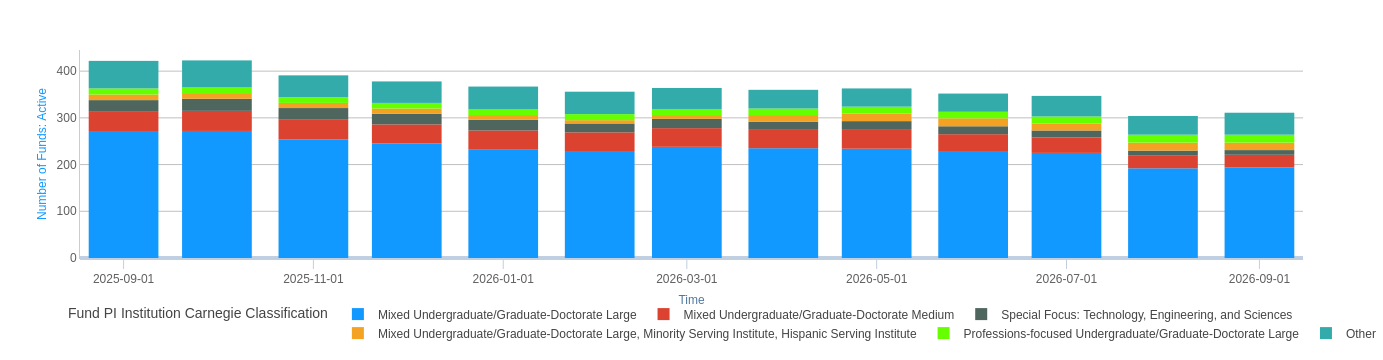

In [45]:
# 2. Grab the top N. Then, sum the remainder and add that as another dataframe column.
# remember, head() sorts the rows!
# top_10 = df.head(10)

# the good news is, this data comes to you sorted from the dw (first dimension value is the dominant one)
# get the first n columns with 'iloc' (n out of 29)
select_top_n=5
top_n = df.iloc[:, :select_top_n]

# Now for the "Other" category: pick up "bottom": iloc n+1 to end
bottom = df.iloc[:, select_top_n:]
display(bottom)
bottom.shape

# we put the remainder column in our top n df:
top_n["Other"]=bottom.sum(axis="columns")
display(top_n)
top_n.shape

# and plot that top N:
plot = px.bar(top_n, labels={'value': metric_name})
plot.show()

Fund PI Institution Carnegie Classification,Mixed Undergraduate/Graduate-Doctorate Large,Mixed Undergraduate/Graduate-Doctorate Medium,"Special Focus: Technology, Engineering, and Sciences","Mixed Undergraduate/Graduate-Doctorate Large, Minority Serving Institute, Hispanic Serving Institute",Professions-focused Undergraduate/Graduate-Doctorate Large,Other
Time,,,,,,
2025-09-01,270.0,43.0,25.0,12.0,13.0,59.0
2025-10-01,272.0,43.0,26.0,12.0,12.0,58.0
2025-11-01,254.0,42.0,25.0,11.0,12.0,47.0
2025-12-01,245.0,41.0,23.0,11.0,12.0,46.0
2026-01-01,233.0,40.0,23.0,10.0,12.0,49.0
2026-02-01,229.0,40.0,19.0,7.0,13.0,48.0
2026-03-01,238.0,40.0,20.0,8.0,13.0,45.0
2026-04-01,235.0,41.0,16.0,14.0,14.0,40.0
2026-05-01,234.0,42.0,17.0,16.0,15.0,39.0


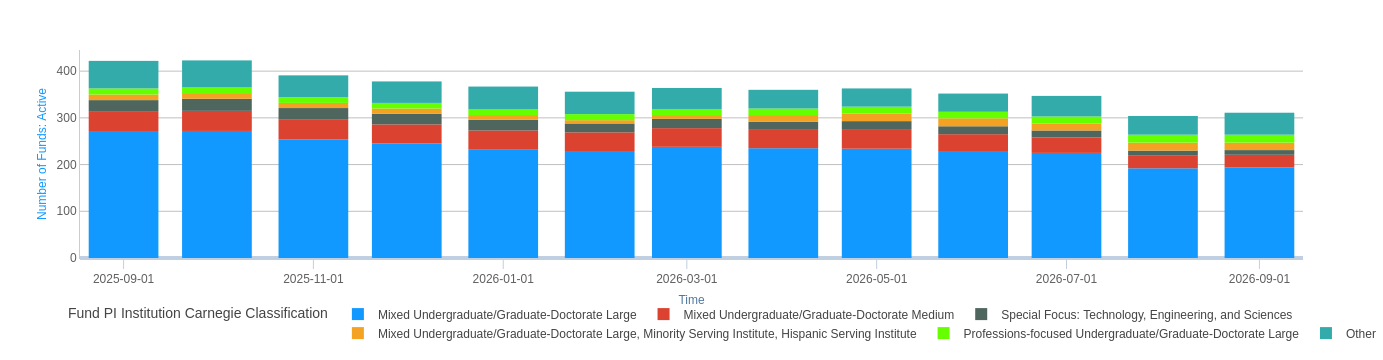

In [47]:
# 2. Grab the top N. Sum the remainder and add that as another dataframe column.
# remember, head() sorts the rows!
# top_10 = df.head(10)

# the good news is, this data comes to you sorted from the dw (first dimension value is the dominant one)
# get the first n columns with 'iloc' (n out of 29)
select_top_n=5
top_n = df.iloc[:, :select_top_n]
#display(top_n) 
#top_n.shape

# Now for the "Other" category: pick up "bottom": iloc n+1 to end
bottom = df.iloc[:, select_top_n:]
#display(bottom)
#bottom.shape

# we put the remainder column in our top n df:
top_n["Other"]=bottom.sum(axis="columns")
display(top_n)
top_n.shape

# and plot the top N categories, showing the bottom N-1 remainder in the "Other" category:
plot = px.bar(top_n, labels={'value': metric_name})
plot.show()

### Dataset Type

The **dataset type** can either be 'timeseries' (the default), in which data are grouped by a time [aggregation unit](#Aggregation-unit), or 'aggregate', in which the data are aggregated across the entire [duration](#Duration). For 'aggregate', the results are returned as a Pandas Series rather than a DataFrame.

The code below shows how to create a bar plot of data aggregated over four months, grouped by resource.

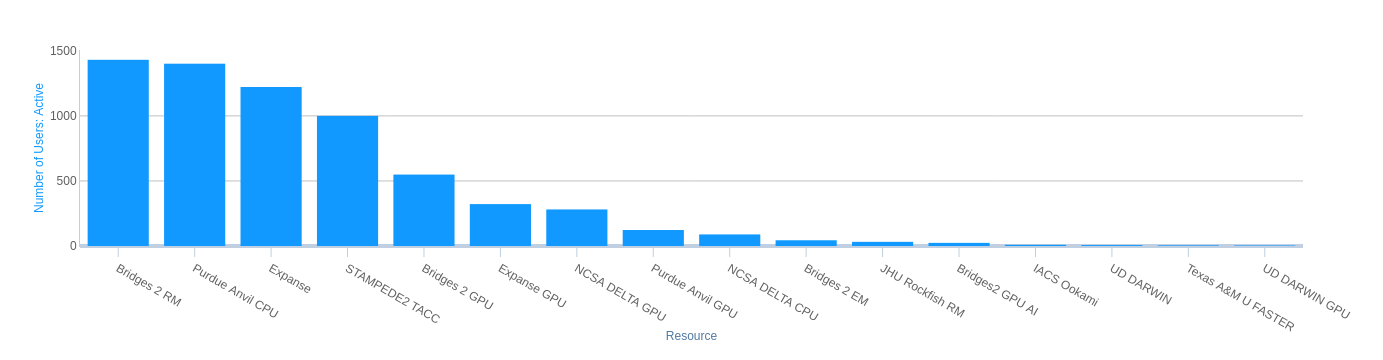

In [48]:
metric_label = 'Number of Users: Active'
with dw:
    df = dw.get_data(
        duration=('2023-01-01', '2023-04-30'),
        realm='Jobs',
        metric=metric_label,
        dimension='Resource',
        dataset_type='aggregate',
    )
plot = px.bar(df, labels={'value': metric_label})
plot.update_layout(
    showlegend=False,
    xaxis_automargin=True,
)
plot.show()

### Aggregation unit

The **aggregation unit** specifies how data are aggregated by time. You can get a list of valid aggregation units by calling the `get_aggregation_units()` method.

In [49]:
with dw:
    display(dw.get_aggregation_units())

('Auto', 'Day', 'Month', 'Quarter', 'Year')

## Choropleth example

As another example of the types of visualizations you can make using the Data Analytics Framework, the code cell below gets the total number of users in each US state (based on the location of the users' institutions) and displays a choropleth map.

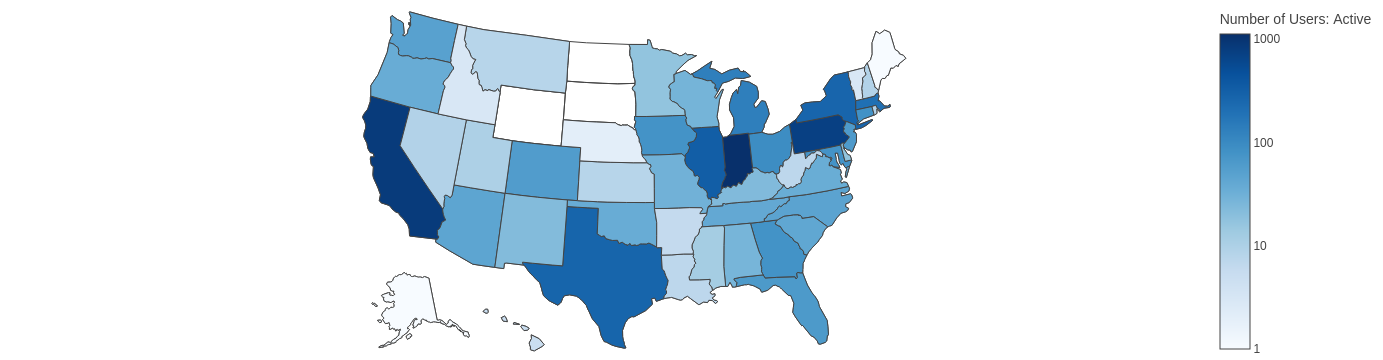

In [50]:
state_names_to_abbreviations = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'District of Columbia': 'DC',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Guam': 'GU',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Puerto Rico': 'PR',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'US Virgin Islands': 'VI',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
}
metric = 'Number of Users: Active'
with dw:
    df = dw.get_data(
        duration=('2023-01-01', '2023-04-30'),
        realm='Jobs',
        metric=metric,
        dimension='User Institution State',
        filters={
            'User Institution Country': 'United States',
        },
        dataset_type='aggregate',
    ).to_frame().reset_index()
df['Abbreviation'] = df['User Institution State'].map(state_names_to_abbreviations)

# Use logarithmic color scale.
import math
import numpy as np
df['log_value'] = np.log10(df[metric])
max_log_value = math.ceil(df['log_value'].max())
colorbar_tickvals = [i for i in range(0, max_log_value + 1)]
colorbar_ticktext = [10 ** i for i in colorbar_tickvals]

plot = px.choropleth(
    df,
    locations='Abbreviation',
    color_continuous_scale=px.colors.sequential.Blues,
    color='log_value',
    locationmode='USA-states',
    scope='usa',
    hover_data=['User Institution State', metric],
)
plot.update_layout(
    margin={'b': 0.5, 't': 0.5},
)
plot.update_coloraxes(
    colorbar_tickmode='array',
    colorbar_tickvals=colorbar_tickvals,
    colorbar_ticktext=colorbar_ticktext,
    colorbar_title_text=metric,
)
plot.update_traces(
    hovertemplate='%{customdata[0]}: %{customdata[1]}',
)
plot.show()

## Additional examples

For additional examples, please see the [xdmod-notebooks repository](https://github.com/ubccr/xdmod-notebooks).

In [ ]:
# This cell is used to create the footer of this notebook.
from xdmod_data.report import footer
footer({
    'history': [
        ['1', '2023-07-21', 'Initial version'],
        ['2', '2024-09-27', 'Add more example plots and update documentation'],
        ['3', '2025-07-18', 'Update for JupyterHub support, add choropleth example'],
    ],
})